<a href="https://colab.research.google.com/github/rakshatpoojary11/raksha/blob/main/mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FIRST FIVE RECORDS
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


LAST FIVE RECORDS
      age     sex    bmi  children smoker     region     charges
1333   50    male  30.97         3     no  northwest  10600.5483
1334   18  female  31.92         0     no  northeast   2205.9808
1335   18  female  36.85         0     no  southeast   1629.8335
1336   21  female  25.80         0     no  southwest   2007.9450
1337   61  female  29.07         0    yes  northwest  29141.3603


DATASET SHAPE
Number of rows: 1338
Number of columns: 7


COLUMN NAMES
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


DATASET INFORMATION
<cla

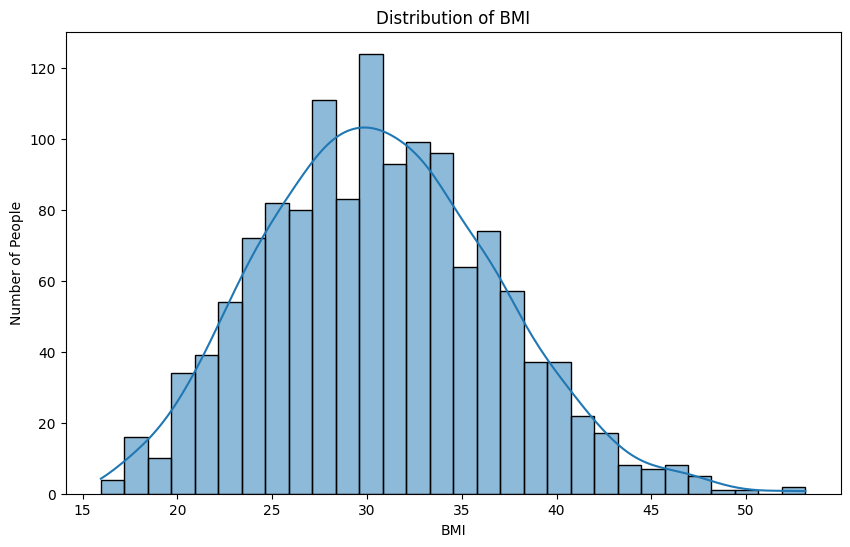

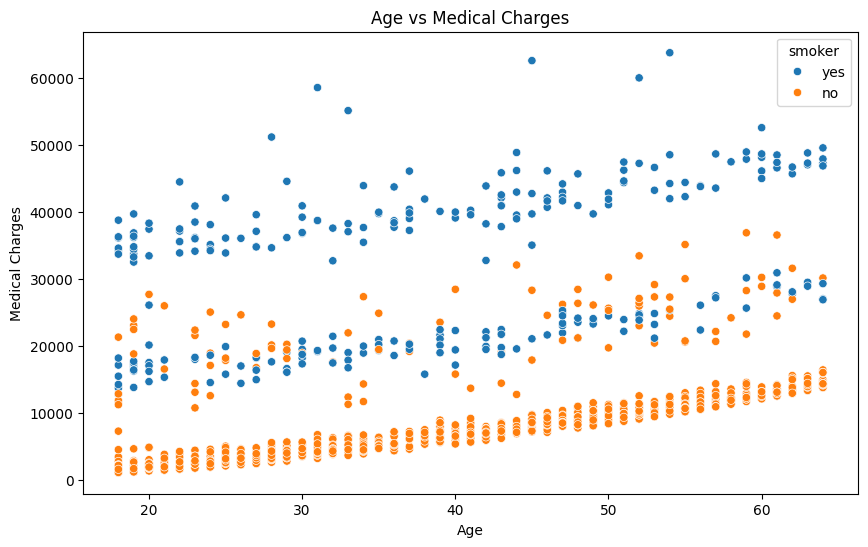

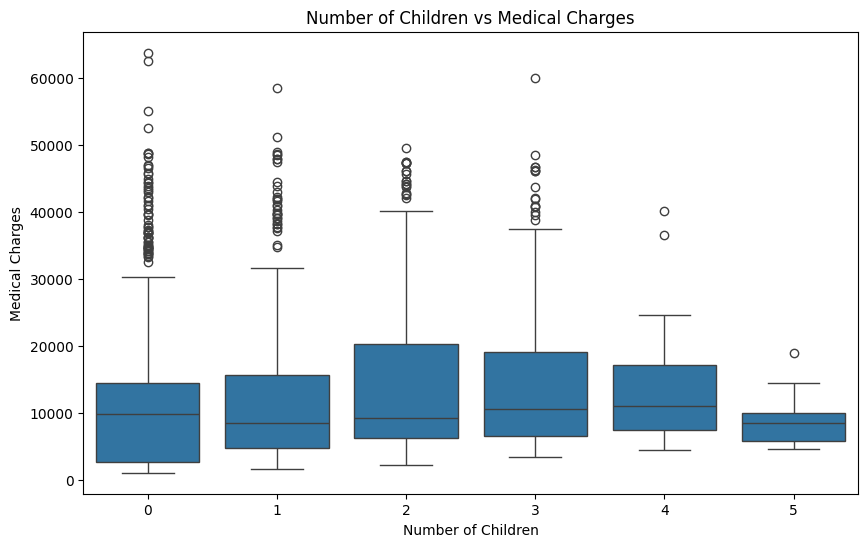

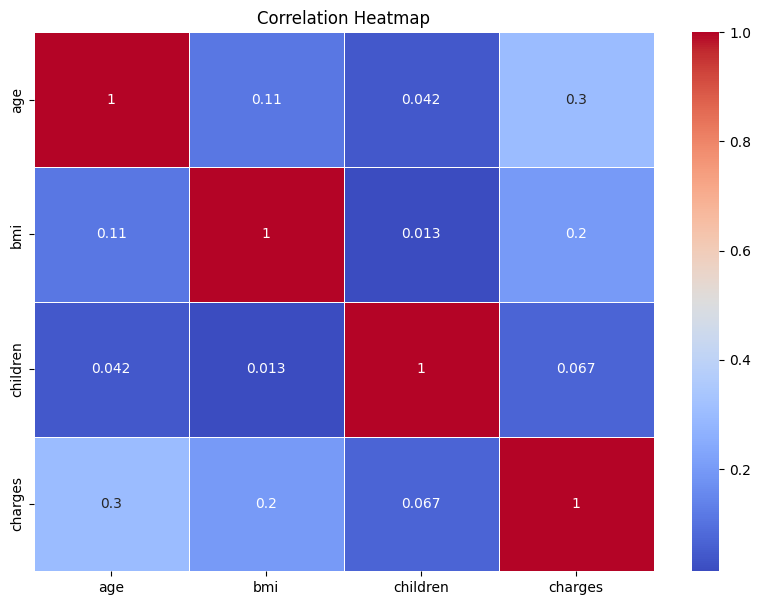



TRAINING AND TESTING DATA
Training records: 1069
Testing records: 268


MODEL TRAINING COMPLETED
Linear Regression model trained successfully.


ACTUAL VS PREDICTED VALUES
    Actual Charges  Predicted Charges
0       8688.85885        8143.693884
1       5708.86700        5737.115683
2      11436.73815       14369.314876
3      38746.35510       31745.513636
4       4463.20510        8962.386657
5       9304.70190       13149.722353
6      38511.62830       30446.760679
7       2150.46900        1453.288813
8       7345.72660       10633.018402
9      10264.44210       11318.943794
10     13415.03810       10377.853573
11     24393.62240       33118.437664
12     37607.52770       31077.252738
13     13063.88300       17411.925288
14     24915.04626       10801.674283


MODEL PERFORMANCE
Mean Absolute Error  : 4177.05
Mean Squared Error   : 35478020.68
Root Mean Squared Error: 5956.34
R2 Score             : 0.8069


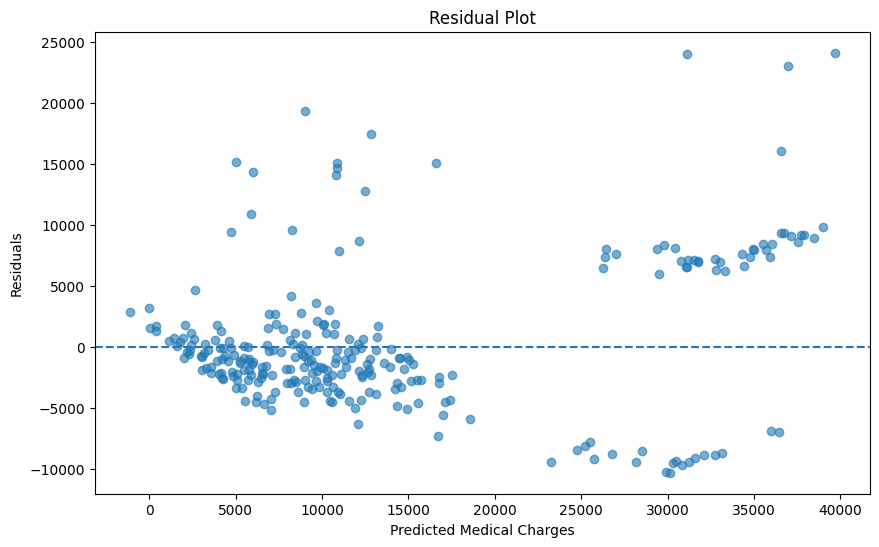



NEW PERSON MEDICAL COST PREDICTION
Age       : 30
Sex       : male
BMI       : 25.5
Children  : 1
Smoker    : no
Region    : southwest

Predicted Medical Cost: ₹ 4252.88


MEDICAL COST PREDICTION PROJECT COMPLETED


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
data = pd.read_csv("insurance.csv")
print("=" * 60)
print("FIRST FIVE RECORDS")
print("=" * 60)
print(data.head())
print("\n")
print("=" * 60)
print("LAST FIVE RECORDS")
print("=" * 60)
print(data.tail())
print("\n")
print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])
print("\n")
print("=" * 60)
print("COLUMN NAMES")
print("=" * 60)
print(data.columns)
print("\n")
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
data.info()
print("\n")
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)
print(data.isnull().sum())
print("\n")
print("=" * 60)
print("DUPLICATE RECORDS")
print("=" * 60)
print("Number of duplicate rows:",data.duplicated().sum())
data = data.drop_duplicates()
print("\n")
print("=" * 60)
print("STATISTICAL DESCRIPTION")
print("=" * 60)
print(data.describe())
print("\n")
print("=" * 60)
print("UNIQUE VALUES")
print("=" * 60)
print("\nSex:")
print(data["sex"].unique())
print("\nSmoker:")
print(data["smoker"].unique())
print("\nRegion:")
print(data["region"].unique())
plt.figure(figsize=(10, 6))
sns.histplot(data["bmi"],bins=30,kde=True)
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Number of People")
plt.show()
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data,x="age",y="charges",hue="smoker")
plt.title("Age vs Medical Charges")
plt.xlabel("Age")
plt.ylabel("Medical Charges")
plt.show()
plt.figure(figsize=(10, 6))
sns.boxplot(data=data,x="children",y="charges")
plt.title("Number of Children vs Medical Charges")
plt.xlabel("Number of Children")
plt.ylabel("Medical Charges")
plt.show()
numeric_data = data.select_dtypes(include=["int64", "float64"])
correlation = numeric_data.corr()
plt.figure(figsize=(10, 7))
sns.heatmap(correlation,annot=True,cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()
X = data.drop("charges", axis=1)
y = data["charges"]
categorical_columns = ["sex","smoker","region"]
numerical_columns = ["age","bmi","children"]
preprocessor = ColumnTransformer(transformers=[("categorical",OneHotEncoder(handle_unknown="ignore"),categorical_columns)],remainder="passthrough")
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)
print("\n")
print("=" * 60)
print("TRAINING AND TESTING DATA")
print("=" * 60)
print("Training records:", len(X_train))
print("Testing records:", len(X_test))
model = Pipeline(
    steps=[("preprocessor",preprocessor),("regressor",LinearRegression())])
model.fit(X_train,y_train)
print("\n")
print("=" * 60)
print("MODEL TRAINING COMPLETED")
print("=" * 60)
print("Linear Regression model trained successfully.")
y_pred = model.predict(X_test)
comparison = pd.DataFrame({"Actual Charges": y_test.values,"Predicted Charges": y_pred})
print("\n")
print("=" * 60)
print("ACTUAL VS PREDICTED VALUES")
print("=" * 60)
print(comparison.head(15))
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
print("\n")
print("=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)
print("Mean Absolute Error  :", round(mae, 2))
print("Mean Squared Error   :", round(mse, 2))
print("Root Mean Squared Error:", round(rmse, 2))
print("R2 Score             :", round(r2, 4))
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred,residuals,alpha=0.6)
plt.axhline(y=0,linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Predicted Medical Charges")
plt.ylabel("Residuals")
plt.show()
new_person = pd.DataFrame({
    "age": [30],
    "sex": ["male"],
    "bmi": [25.5],
    "children": [1],
    "smoker": ["no"],
    "region": ["southwest"]
})
new_prediction = model.predict(new_person)
print("\n")
print("=" * 60)
print("NEW PERSON MEDICAL COST PREDICTION")
print("=" * 60)
print("Age       :", 30)
print("Sex       :", "male")
print("BMI       :", 25.5)
print("Children  :", 1)
print("Smoker    :", "no")
print("Region    :", "southwest")
print("\nPredicted Medical Cost: ₹",round(new_prediction[0], 2))
print("\n")
print("=" * 60)
print("MEDICAL COST PREDICTION PROJECT COMPLETED")
print("=" * 60)